In [1]:
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cuda:0


100%|██████████| 170498071/170498071 [00:02<00:00, 83556325.76it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified

Report for epoch: 1
valid accuracy: 54.4200, valid loss: 45.5800
train accuracy: 55.7133, train loss: 44.2867


Report for epoch: 2
valid accuracy: 60.2600, valid loss: 39.7400
train accuracy: 61.8378, train loss: 38.1622


Report for epoch: 3
valid accuracy: 62.5800, valid loss: 37.4200
train accuracy: 65.3467, train loss: 34.6533


Report for epoch: 4
valid accuracy: 64.0200, valid loss: 35.9800
train accuracy: 68.5378, train loss: 31.4622


Report for epoch: 5
valid accuracy: 67.3000, valid loss: 32.7000
train accuracy: 71.4422, train loss: 28.5578


Report for epoch: 6
valid accuracy: 66.4400, valid loss: 33.5600
train accuracy: 73.0378, train loss: 26.9622


Report for epoch: 7
valid accuracy: 65.7000, valid loss: 34.3000
train accuracy: 72.6067, train loss: 27.3933


Report for epoch: 8
valid accuracy: 66.8200, valid loss: 33.1800
train accuracy: 75.6622, train loss: 24.3378


Report for epo

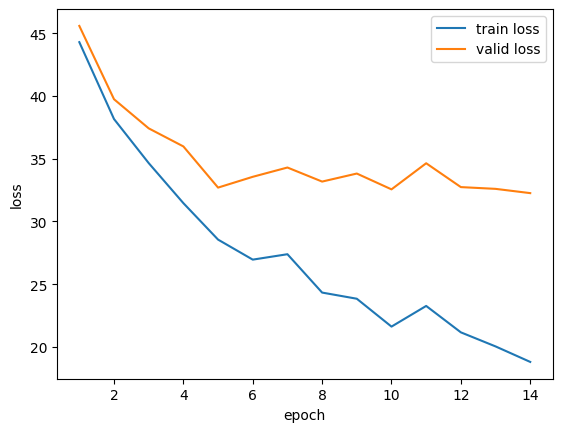

In [2]:
from torch.nn.modules.dropout import Dropout
#مقدار دهی اولیه
batch_size = 32
learning_rate=0.001
model_name='ب'



import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import os
import time


# محاسبه دقت
def calculate_accuracy(dataloader):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in dataloader:
            images, labels = data
            images, labels = images.cuda(), labels.cuda()
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = round(100 * correct / total, 4)  # اعشار 4 رقمی
    return accuracy



#ساخت Loader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # نرمال سازی
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

#یک پنجم دیتا آموزش به صورت تصادفی به عنوان دیتا valid
trainset, validset = random_split(trainset,[45000,5000])
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2,pin_memory=True)
validloader = torch.utils.data.DataLoader(validset, batch_size=batch_size,
                                          shuffle=False, num_workers=2,pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2,pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


import torch.nn as nn
import torch.nn.functional as F


class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=4, bias=True)
        self.pool1 = nn.MaxPool2d(2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=4, bias=True)
        self.pool2 = nn.MaxPool2d(2, stride=2)

        # Classification layers
        self.fc1 = nn.Linear(32 * 5 * 5, 256)
        self.dropout = nn.Dropout(p=0.3)  # Dropout layer
        self.fc2 = nn.Linear(256, 10)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)  # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout
        x = self.fc2(x)
        return x

net = Network()
if torch.cuda.is_available():
  net = net.to(torch.device("cuda:0"))



import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=learning_rate)


epoch=0
stop_condition=False

accuracy_list_valid=[]
error_list_train_plot=[]
error_list_valid_plot=[]


#Training part
start_time = time.time()
while (epoch < 20 and not stop_condition):
    for i, data in enumerate(trainloader, 0):

        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.cuda(), labels.cuda()

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        #print(outputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()


    epoch+=1


    accuracy_valid=calculate_accuracy(validloader)
    accuracy_train=calculate_accuracy(trainloader)
    print(f'\nReport for epoch: {epoch}')
    print(f'valid accuracy: {accuracy_valid:.4f}, valid loss: {100-accuracy_valid:.4f}')
    print(f'train accuracy: {accuracy_train:.4f}, train loss: {100-accuracy_train:.4f}\n')


    error_list_valid_plot.append(100-accuracy_valid)
    error_list_train_plot.append(100-accuracy_train)
    accuracy_list_valid.append(accuracy_valid)

    #check stop condition
    last_3_acc = accuracy_list_valid[-3:]
    if max(last_3_acc) - sum(last_3_acc) / 3 <= 0.3:
        stop_condition = True
end_time = time.time()



#Report generating
avg_epoch_runtime=(end_time-start_time)/epoch

print("================================\n")
print(f"(Training finished in {epoch} epochs)")
print(f"Average epoch's runtime: {avg_epoch_runtime} seconds")
print(f'accuracy on test data: {calculate_accuracy(testloader):.4f}, loss of test data: {100-calculate_accuracy(testloader):.4f}\n\n')


if (os.path.exists('/content/drive/MyDrive/model')==False):
  os.mkdir('/content/drive/MyDrive/model')
PATH = '/content/drive/MyDrive/model/'+model_name+'.pth'
torch.save(net.state_dict(), PATH)


dataiter = iter(testloader)
images, labels = next(dataiter)


#load model
net = Network()
net.load_state_dict(torch.load(PATH))


#Drawing plot
import numpy as np
import matplotlib.pyplot as plt

x=list(range(1,len(error_list_train_plot)+1))

x=np.array(x)
y_train=np.array(error_list_train_plot)
y_valid=np.array(error_list_valid_plot)

plt.plot(x,y_train)
plt.plot(x,y_valid)
plt.xlabel("epoch")
plt.ylabel('loss')
plt.legend(['train loss', 'valid loss'])
plt.savefig('/content/drive/MyDrive/model/'+model_name+'.png')
plt.show()